# 1-Shot OCL Comparison (Fig. 3a / Table 1)

Reproduces the 1-shot OpenLORIS accuracy trend for all 8 main classifiers
(CLP, CLP-SNN, and six baselines: Perceptron, Fine Tune, NCM, Replay, SLDA, SLDA Frozen Σ).

**Protocol**: 40 classes × 60 frames, streamed one frame at a time.  
Evaluation after every class boundary (40 checkpoints). Mean ± std across seeds [10, 20, 30].

Run the experiment script first (or set `RUN_EXPERIMENT = True` below to run inline):
```bash
python experiments/clp_vs_baselines_1shot.py
```

For the deep-dive into the **CLP-SNN integer/float quantization variants**, see
`notebooks/06_clp_snn_variants_1shot.ipynb` (uses `experiments/clp_vs_clp_snn_1shot.py`).

In [10]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

REPO = Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

RESULTS_DIR = REPO / "experiments" / "results" / "clp_vs_baselines_1shot"
IMAGES_DIR  = REPO / "images"
IMAGES_DIR.mkdir(exist_ok=True)

RUN_EXPERIMENT = False  # set True to re-run (slow: ~30 min)

In [11]:
if RUN_EXPERIMENT:
    import subprocess
    subprocess.run([sys.executable, str(REPO / "experiments" / "clp_vs_baselines_1shot.py")],
                   check=True)

## Load results

In [12]:
data = np.load(RESULTS_DIR / "accuracies.npz", allow_pickle=True)
accuracies   = data["accuracies"]    # (40, 8, 3)
VARIANTS     = list(data["variant_names"])
N_STEPS      = accuracies.shape[0]

mean_acc = accuracies.mean(axis=2)
std_acc  = accuracies.std(axis=2)

print(f"Shape: {accuracies.shape}  — ({N_STEPS} steps, {len(VARIANTS)} variants, 3 seeds)")
print("Variants:", VARIANTS)

Shape: (40, 8, 3)  — (40 steps, 8 variants, 3 seeds)
Variants: ['Perceptron', 'Fine Tuning', 'NCM', 'Replay', 'SLDA', 'SLDA (Frozen Σ)', 'CLP', 'CLP-SNN']


## Accuracy trend (Fig. 3a)

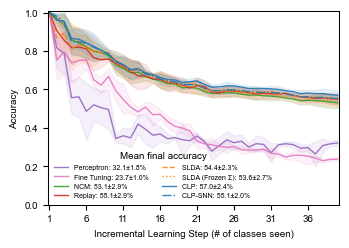

Saved to c:\Users\elvin\dev\CLP-SNN\images


In [13]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 5.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.75,
    "savefig.dpi": 600,
})

p = sns.color_palette("tab10")
colors = [p[4], p[6], p[2], p[3], p[1], p[1], p[0], p[0]]
dashes = ["-", "-", "-", "-", "--", ":", "-", "-."]

t = np.arange(1, N_STEPS + 1)
fig, ax = plt.subplots(figsize=(3.5, 2.5))

for c, name in enumerate(VARIANTS):
    label = f"{name}: {mean_acc[-1,c]*100:.1f}±{std_acc[-1,c]*100:.1f}%"
    ax.plot(t, mean_acc[:, c], color=colors[c], linestyle=dashes[c],
            linewidth=1.0, label=label, alpha=0.9)
    ax.fill_between(t, mean_acc[:, c] - std_acc[:, c],
                       mean_acc[:, c] + std_acc[:, c],
                    color=colors[c], alpha=0.1)

ax.set_xlabel("Incremental Learning Step (# of classes seen)")
ax.set_ylabel("Accuracy")
ax.set_ylim([0, 1.01])
ax.set_xlim([0.8, N_STEPS + 0.2])
ax.set_xticks(t[::5])
ax.legend(title="Mean final accuracy", loc="lower left",
          frameon=False, ncol=2, fontsize=5)
plt.tight_layout()

for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"acc_trend_1shot_baselines.{ext}", format=ext, bbox_inches="tight")
plt.show()
print("Saved to", IMAGES_DIR)

## Final accuracy table (Table 1 — 1-shot accuracy column)

In [14]:
df = pd.DataFrame({
    "Variant": VARIANTS,
    "Mean (%)": [f"{mean_acc[-1,c]*100:.2f}" for c in range(len(VARIANTS))],
    "Std (%)": [f"{std_acc[-1,c]*100:.2f}" for c in range(len(VARIANTS))],
})
df

,Variant,Mean (%),Std (%)
0,Perceptron,32.14,1.84
1,Fine Tuning,23.67,0.97
2,NCM,53.06,2.90
3,Replay,55.07,2.93
4,SLDA,54.42,2.33
5,SLDA (Frozen Σ),53.64,2.74
6,CLP,56.97,2.35
7,CLP-SNN,55.12,1.95
